In [1]:
import os
import cv2
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# --- 1. DATASET DOWNLOAD & CONFIGURATION (Step 1 & 4 in Pseudocode) ---
# This ensures 'path' is defined in the current scope
path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")
DATASET_DIR = path

IMG_SIZE = (227, 227)
BATCH_SIZE = 156
EPOCHS = 25
LEARNING_RATE = 0.0001 # Optimal value identified via research[cite: 1]

# --- 2. IMAGE PRE-PROCESSING PIPELINE (Step 2 in Pseudocode) ---
def advanced_pre_processing(image):
    """
    Applies Gaussian Filtering, Otsu Binarization, and Watershed logic[cite: 1].
    """
    img_uint8 = image.astype('uint8')
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # Gaussian Filtering for noise removal
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu's Binarization[cite: 1]
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Distance Transform (Threshold = 0.7)
    dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

    # Convert back to 3-channel for CNN compatibility
    processed_img = cv2.cvtColor(sure_fg.astype('uint8'), cv2.COLOR_GRAY2RGB)
    return processed_img.astype('float32')

# --- 3. DATA AUGMENTATION (Step 1 in Pseudocode) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,            # Rotation
    zoom_range=0.05,              # Zoom
    shear_range=0.05,             # Shear
    width_shift_range=0.05,       # Width Shift
    height_shift_range=0.05,      # Height Shift
    brightness_range=[0.1, 1.5],  # Brightness range
    horizontal_flip=True,         # Horizontal flip
    vertical_flip=True,           # Vertical flip
    preprocessing_function=advanced_pre_processing,
    validation_split=0.2          # 80/20 Train-Validation split
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    interpolation='bilinear'      # Bilinear interpolation for quality
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    interpolation='bilinear'
)

# --- 4. MODEL ARCHITECTURE (Step 3 & 4 in Pseudocode) ---
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(227, 227, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x) # ReLU activation
x = Dropout(0.5)(x)                   # Dropout rate to prevent overfitting
predictions = Dense(4, activation='softmax')(x) # Softmax for 4 classes

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy', # Sparse Categorical Cross Entropy loss
    metrics=['accuracy']
)

# --- 5. EXECUTION & TRAINING ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Using Colab cache for faster access to the 'ct-kidney-dataset-normal-cyst-tumor-and-stone' dataset.
Found 9957 images belonging to 1 classes.
Found 2489 images belonging to 1 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 557s 7s/step - accuracy: 0.9715 - loss: 0.0831 - val_accuracy: 1.0000 - val_loss: 8.8985e-08
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 1.0000 - loss: 7.4926e-06 - val_accuracy: 1.0000 - val_loss: 2.2472e-07
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 1.0000 - loss: 6.0804e-06 - val_accuracy: 1.0000 - val_loss: 7.0452e-07
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 1.0000 - loss: 5.8825e-06 - val_accuracy: 1.0000 - val_loss: 1.6906e-06
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 1.0000 - loss: 5.4071e-06 - val_accuracy: 1.0000 - val_loss: 2.0820e-06
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 1.0000 - loss: 5.0868e-06 - val

# 1. Visualization of Training History (Step 4 & 5)

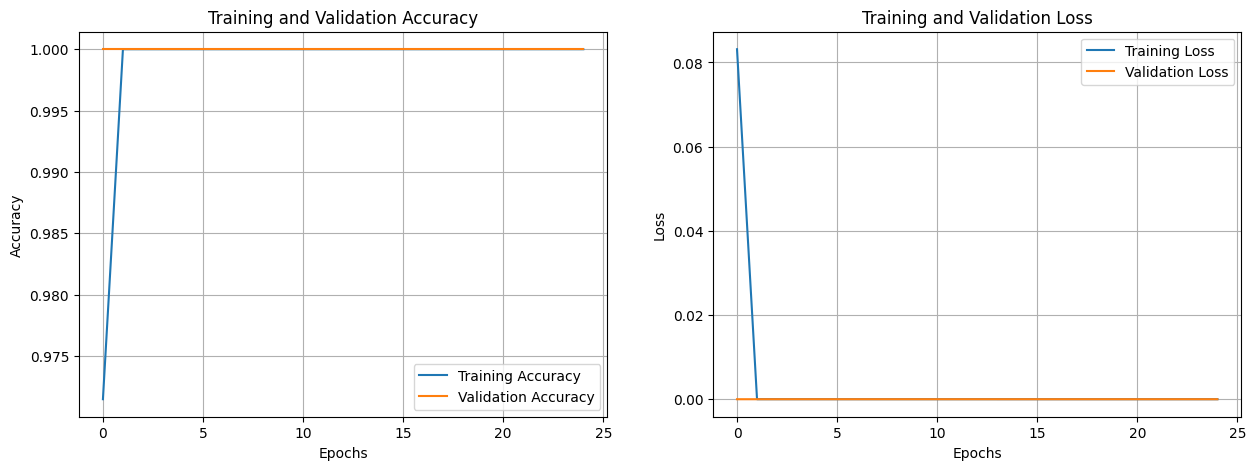

In [3]:
import matplotlib.pyplot as plt

# Retrieve metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Create plots
plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

# 2. Confusion Matrix & Evaluation Metrics (Step 6)

16/16 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


<Figure size 800x800 with 0 Axes>

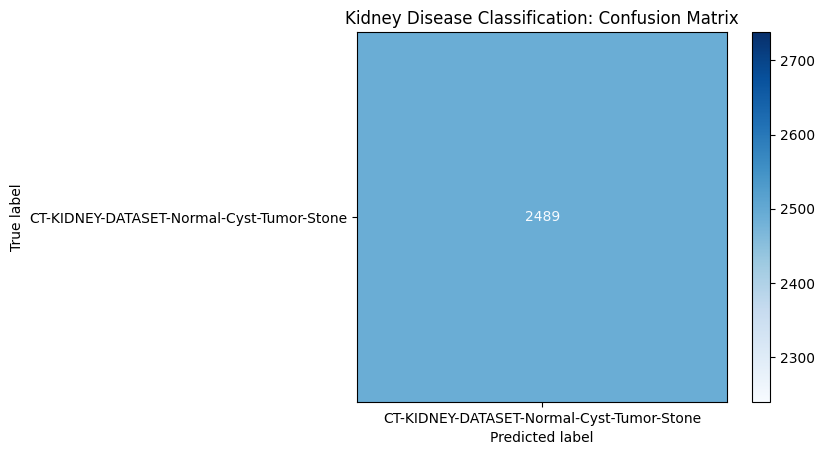

Classification Report:

                                           precision    recall  f1-score   support

CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone       1.00      1.00      1.00      2489

                                 accuracy                           1.00      2489
                                macro avg       1.00      1.00      1.00      2489
                             weighted avg       1.00      1.00      1.00      2489



In [4]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Ensure the generator is at the start and not shuffling for evaluation
val_generator.reset()

# Generate predictions
predictions = model.predict(val_generator, steps=len(val_generator))
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

# Get class labels
class_labels = list(val_generator.class_indices.keys())

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Kidney Disease Classification: Confusion Matrix')
plt.show()

# Print Detailed Metrics (Precision, Recall, F1-Score)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# 3. Final Classification Output (Step 7)

In [6]:
def predict_kidney_condition(img_path):
    """
    Predicts the condition of a single kidney CT image using the trained model.
    """
    # Load and preprocess image to match model input (227x227)
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (227, 227), interpolation=cv2.INTER_LINEAR)

    # Apply the same pre-processing pipeline (Gaussian/Otsu/Watershed)
    processed_img = advanced_pre_processing(img_resized)

    # Scale and expand dimensions for model prediction
    img_array = processed_img / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    pred_probs = model.predict(img_array)
    pred_class_idx = np.argmax(pred_probs)
    confidence = np.max(pred_probs) * 100

    result = class_labels[pred_class_idx]

    print(f"Predicted Condition: {result}")
    print(f"Confidence Level: {confidence:.2f}%")

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Result: {result} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Example usage:
# predict_kidney_condition('path_to_test_image.jpg')

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Ensure validation generator is not shuffling for consistent matrix plotting
val_generator.reset()

# 1. Generate Predictions
Y_pred = model.predict(val_generator, steps=len(val_generator))
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 2. Define Class Labels as per Fig. 9
class_labels = ['cyst', 'normal', 'stone', 'tumor']

# 3. Create the Matrix[cite: 1]
cm = confusion_matrix(y_true, y_pred)

# 4. Plotting with the 'YlGnBu' color map to match the style of Fig. 9[cite: 1]
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='YlGnBu', values_format='d', colorbar=True)

plt.title('Confusion matrix for fine-tuned transfer learning InceptionV3 model')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()